<a href="https://colab.research.google.com/github/hduowg28/machine-learning/blob/main/housing_prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score , confusion_matrix , mean_absolute_error , mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


### read dataset

In [3]:
dataset=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ames-housing-prices/AmesHousing.csv')

### Target variable

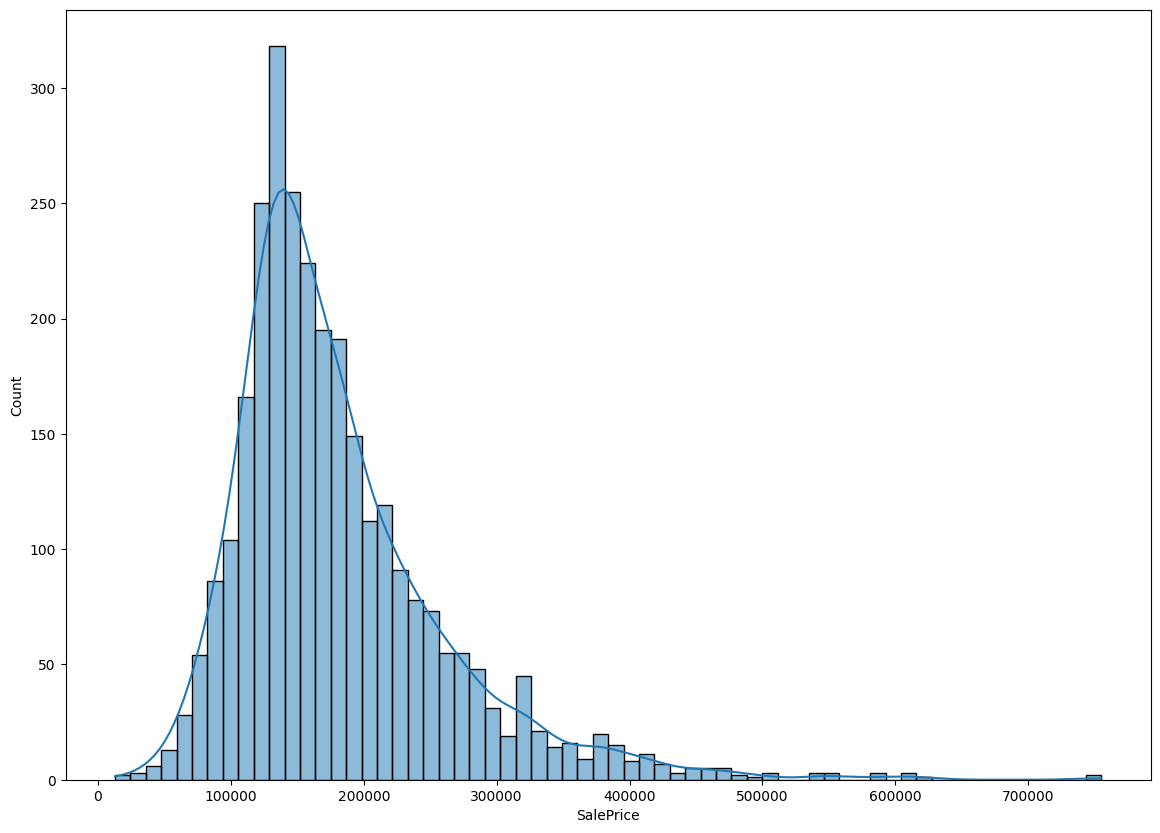

In [4]:
plt.figure(figsize = (14,10))
sns.histplot(dataset['SalePrice'], kde=True);

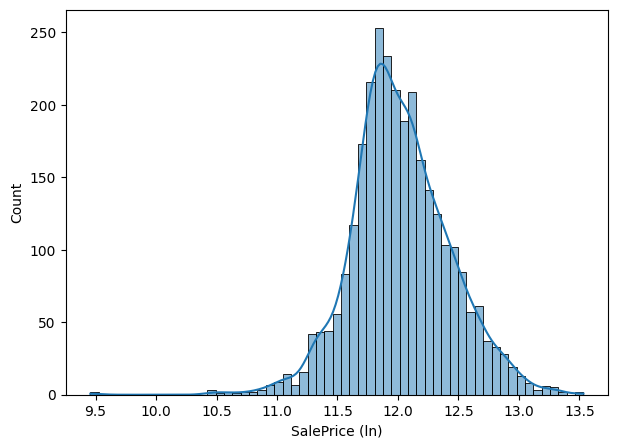

In [ ]:
plt.figure(figsize=(7, 5))
sns.histplot(np.log1p(dataset["SalePrice"]), kde=True)

plt.xlabel("SalePrice (ln)")
plt.show()

In [ ]:
dataset.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

### EDA

In [5]:
dataset.dtypes

,0
Order,int64
PID,int64
MS SubClass,int64
MS Zoning,object
Lot Frontage,float64
...,...
Mo Sold,int64
Yr Sold,int64
Sale Type,object
Sale Condition,object


In [6]:
dataset.isnull().sum()

,0
Order,0
PID,0
MS SubClass,0
MS Zoning,0
Lot Frontage,490
...,...
Mo Sold,0
Yr Sold,0
Sale Type,0
Sale Condition,0


In [7]:
# dataset[dataset["Garage Type"].isnull()]
dataset.value_counts("Garage Type")
# dataset.loc[dataset["Bsmt Qual"].isnull(),["Bsmt Qual", "Bsmt Cond", "Total Bsmt SF"]]
# tim cot du lieu khong co tinh nhat quan
# dataset[
#     dataset["Garage Type"].isnull() != dataset["Garage Qual"].isnull()
# ]


,count
Garage Type,
Attchd,1731
Detchd,782
BuiltIn,186
Basment,36
2Types,23
CarPort,15


In [8]:
dataset.loc[
    dataset["Garage Cars"].isnull(),
    [
        "Garage Type",
        "Garage Cars",
        "Garage Area",
        "Garage Qual",
        "Garage Cond",
        "Garage Finish",
        "Garage Yr Blt",
    ]
]

,Garage Type,Garage Cars,Garage Area,Garage Qual,Garage Cond,Garage Finish,Garage Yr Blt
2236,Detchd,NaN,NaN,NaN,NaN,NaN,NaN


### Fill None value

In [9]:
lot_frontage_median = dataset["Lot Frontage"].median()
dataset["Lot Frontage"] = dataset["Lot Frontage"].fillna(lot_frontage_median)
dataset["Alley"] = dataset["Alley"].fillna("noAlley")
dataset["Mas Vnr Type"] = dataset["Mas Vnr Type"].fillna("none")
dataset["Mas Vnr Area"] = dataset["Mas Vnr Area"].fillna(0)
dataset["Bsmt Qual"] = dataset["Bsmt Qual"].fillna("noBsmt")
dataset["Bsmt Cond"] = dataset["Bsmt Cond"].fillna("noBsmt")
dataset["Bsmt Exposure"] = dataset["Bsmt Exposure"].fillna("noBsmt")
dataset["BsmtFin Type 1"] = dataset["BsmtFin Type 1"].fillna("noBsmt")
dataset["BsmtFin Type 2"] = dataset["BsmtFin Type 2"].fillna("noBsmt")
dataset["BsmtFin SF 1"] = dataset["BsmtFin SF 1"].fillna(0)
dataset["BsmtFin SF 2"] = dataset["BsmtFin SF 2"].fillna(0)
dataset["Bsmt Unf SF"] = dataset["Bsmt Unf SF"].fillna(0)
dataset["Total Bsmt SF"] = dataset["Total Bsmt SF"].fillna(0)
dataset["Bsmt Full Bath"] = dataset["Bsmt Full Bath"].fillna(0)
dataset["Bsmt Half Bath"] = dataset["Bsmt Half Bath"].fillna(0)
dataset["Electrical"] = dataset["Electrical"].fillna(
    dataset["Electrical"].mode()[0]
)
dataset["Fireplace Qu"] = dataset["Fireplace Qu"].fillna("NoFireplace")
# Các dòng không có garage
mask = dataset["Garage Type"].isnull()

# Điền NoGarage cho tất cả thuộc tính garage dạng categorical
garage_cat_cols = [
    "Garage Type",
    "Garage Finish",
    "Garage Qual",
    "Garage Cond",
    "Garage Yr Blt",
]
for col in garage_cat_cols:
    dataset.loc[mask, col] = dataset.loc[mask, col].fillna("NoGarage")

dataset["Garage Yr Blt"] = dataset["Garage Yr Blt"].replace("NoGarage", -1)
dataset["Garage Yr Blt"] = pd.to_numeric(dataset["Garage Yr Blt"])
dataset["Garage Finish"] = dataset["Garage Finish"].fillna(
    dataset["Garage Finish"].mode()[0]
)

dataset["Garage Qual"] = dataset["Garage Qual"].fillna(
    dataset["Garage Qual"].mode()[0]
)

dataset["Garage Cond"] = dataset["Garage Cond"].fillna(
    dataset["Garage Cond"].mode()[0]
)
dataset["Garage Yr Blt"] = dataset["Garage Yr Blt"].fillna(
    dataset["Garage Yr Blt"].mode()[0]
)
dataset["Garage Cars"] = dataset["Garage Cars"].fillna(
    dataset["Garage Cars"].median()
)

dataset["Garage Area"] = dataset["Garage Area"].fillna(
    dataset["Garage Area"].median()
)
dataset["Pool QC"] = dataset["Pool QC"].fillna("NoPool")
dataset["Fence"] = dataset["Fence"].fillna("NoFence")
dataset["Misc Feature"] = dataset["Misc Feature"].fillna("None")
dataset
# dataset["Lot Frontage"].mean()

/tmp/ipykernel_2280/3054482869.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['NoGarage' 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage'
 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage'
 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage'
 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage'
 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage'
 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage'
 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage'
 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage'
 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage'
 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage'
 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage'
 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage' 'NoGarage'
 'NoGarage' 'NoGarage' 'NoGar

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,noAlley,IR1,Lvl,...,0,NoPool,NoFence,None,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,noAlley,Reg,Lvl,...,0,NoPool,MnPrv,None,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,noAlley,IR1,Lvl,...,0,NoPool,NoFence,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,noAlley,Reg,Lvl,...,0,NoPool,NoFence,None,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,noAlley,IR1,Lvl,...,0,NoPool,MnPrv,None,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.0,7937,Pave,noAlley,IR1,Lvl,...,0,NoPool,GdPrv,None,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,68.0,8885,Pave,noAlley,IR1,Low,...,0,NoPool,MnPrv,None,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0,10441,Pave,noAlley,Reg,Lvl,...,0,NoPool,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0,10010,Pave,noAlley,Reg,Lvl,...,0,NoPool,NoFence,None,0,4,2006,WD,Normal,170000



### interaction feature


In [10]:
# Quality-Adjusted Area : Nha rong ma vat lieu xin thi gia tang theo cap so nhan
dataset['Quality_Adjusted_Area'] = dataset['Overall Qual'] * dataset['Gr Liv Area']
# Total Square Footage: tong khong gian (tang ham + mat dat)
dataset['Total_SqFt'] = dataset['Gr Liv Area'] + dataset['Total Bsmt SF']
# Overall Grade:gom diem chat luong va diem bao tri thanh 1 thuoc do rieng
dataset['Overall_Grade'] = dataset['Overall Qual'] + dataset['Overall Cond']
# Total_Bathrooms: Gom cac phong tam full (1 điểm) va half (0.5 điểm) o ca tren va duoi tang ham
dataset['Total_Bathrooms'] = (dataset['Full Bath'] +
                              (0.5 * dataset['Half Bath']) +
                              dataset['Bsmt Full Bath'] +
                              (0.5 * dataset['Bsmt Half Bath']))
#  House Age at Sale : nha cang old gia cang decrease. (year sold - year built)
dataset['House_Age'] = dataset['Yr Sold'] - dataset['Year Built']

# Is Remodeled: binary variable (1=yes, 0=No). Nha da sua (Nam sua khac nam xay dung) thuong ban duoc gia hon
dataset['Is_Remodeled'] = (dataset['Year Remod/Add'] != dataset['Year Built']).astype(int)

print(f"tong so cot hien tai: {dataset.shape[1]}")

tong so cot hien tai: 88


### Outlier filter

In [11]:

# plt.figure(figsize=(10, 6))
# sns.scatterplot(x=dataset['Gr Liv Area'], y=dataset['SalePrice'], alpha=0.6)

# plt.axvline(x=4000, color='red', linestyle='--', label='Area thresh (4000 sqft)')
# plt.axhline(y=300000, color='orange', linestyle='--', label='Price thresh (300k USD)')

# plt.title('Phân tích Outlier: Tỷ lệ Diện tích sống và Giá nhà', fontsize=14)
# plt.xlabel('Diện tích sống phía trên mặt đất (Gr Liv Area)', fontsize=12)
# plt.ylabel('Giá bán (SalePrice)', fontsize=12)
# plt.legend()
# plt.show()


# print(f"Kích thước dữ liệu ban đầu: {dataset.shape}")

# outliers = dataset[(dataset['Gr Liv Area'] > 4000) & (dataset['SalePrice'] < 300000)]
# print(f"Số lượng Outliers được tìm thấy: {len(outliers)} bản ghi")
# # sklearn
# dataset = dataset.drop(outliers.index)

# dataset = dataset.reset_index(drop=True)

# print(f"Kích thước dữ liệu sau khi lọc: {dataset.shape}")

In [12]:
from sklearn.ensemble import IsolationForest

print(f"Kích thước dữ liệu ban đầu: {dataset.shape}")

# Bước 1: Lọc Outlier cực đoan theo khuyến nghị của tác giả bộ dữ liệu (Domain Knowledge)
outliers_manual = dataset[dataset['Gr Liv Area'] > 4000]
print(f"-> Phát hiện {len(outliers_manual)} căn nhà cực đoan theo diện tích (>4000 sqft)")
dataset = dataset.drop(outliers_manual.index, errors='ignore')

# Bước 2: Dùng Isolation Forest quét ĐA CHIỀU trên các đặc trưng cấu trúc cốt lõi
# Chọn các cột số có khả năng xảy ra bất thường về mặt xây dựng
feature_cols_for_outliers = [
    'Gr Liv Area', 'Total_SqFt', 'Garage Area',
    'Total Bsmt SF', 'Lot Frontage', 'House_Age'
]
# Đảm bảo các cột này tồn tại trong bộ dữ liệu hiện tại
feature_cols_for_outliers = [c for c in feature_cols_for_outliers if c in dataset.columns]

# Cố định random_state để RMSE không bị lệch vài trăm USD mỗi lần chạy
iso = IsolationForest(contamination=0.01, random_state=42, n_estimators=150)

# Tiến hành fit_predict dựa trên các đặc trưng (Không bỏ SalePrice vào để chống Data Leakage)
labels = iso.fit_predict(dataset[feature_cols_for_outliers])

# giữ lại các dòng dữ liệu bình thường (label == 1)
num_structural_outliers = (labels == -1).sum()
print(f"-> Thuật toán phát hiện thêm {num_structural_outliers} căn nhà dị biệt về mặt cấu trúc đa chiều.")

dataset = dataset[labels == 1]

# Reset lại index để các bước Target Encoding và K-Fold phía sau không bị lệch dòng
dataset = dataset.reset_index(drop=True)
print(f"Kích thước dữ liệu sạch cuối cùng: {dataset.shape}")


Kích thước dữ liệu ban đầu: (2930, 88)
-> Phát hiện 5 căn nhà cực đoan theo diện tích (>4000 sqft)
-> Thuật toán phát hiện thêm 30 căn nhà dị biệt về mặt cấu trúc đa chiều.
Kích thước dữ liệu sạch cuối cùng: (2895, 88)


### correlation graph

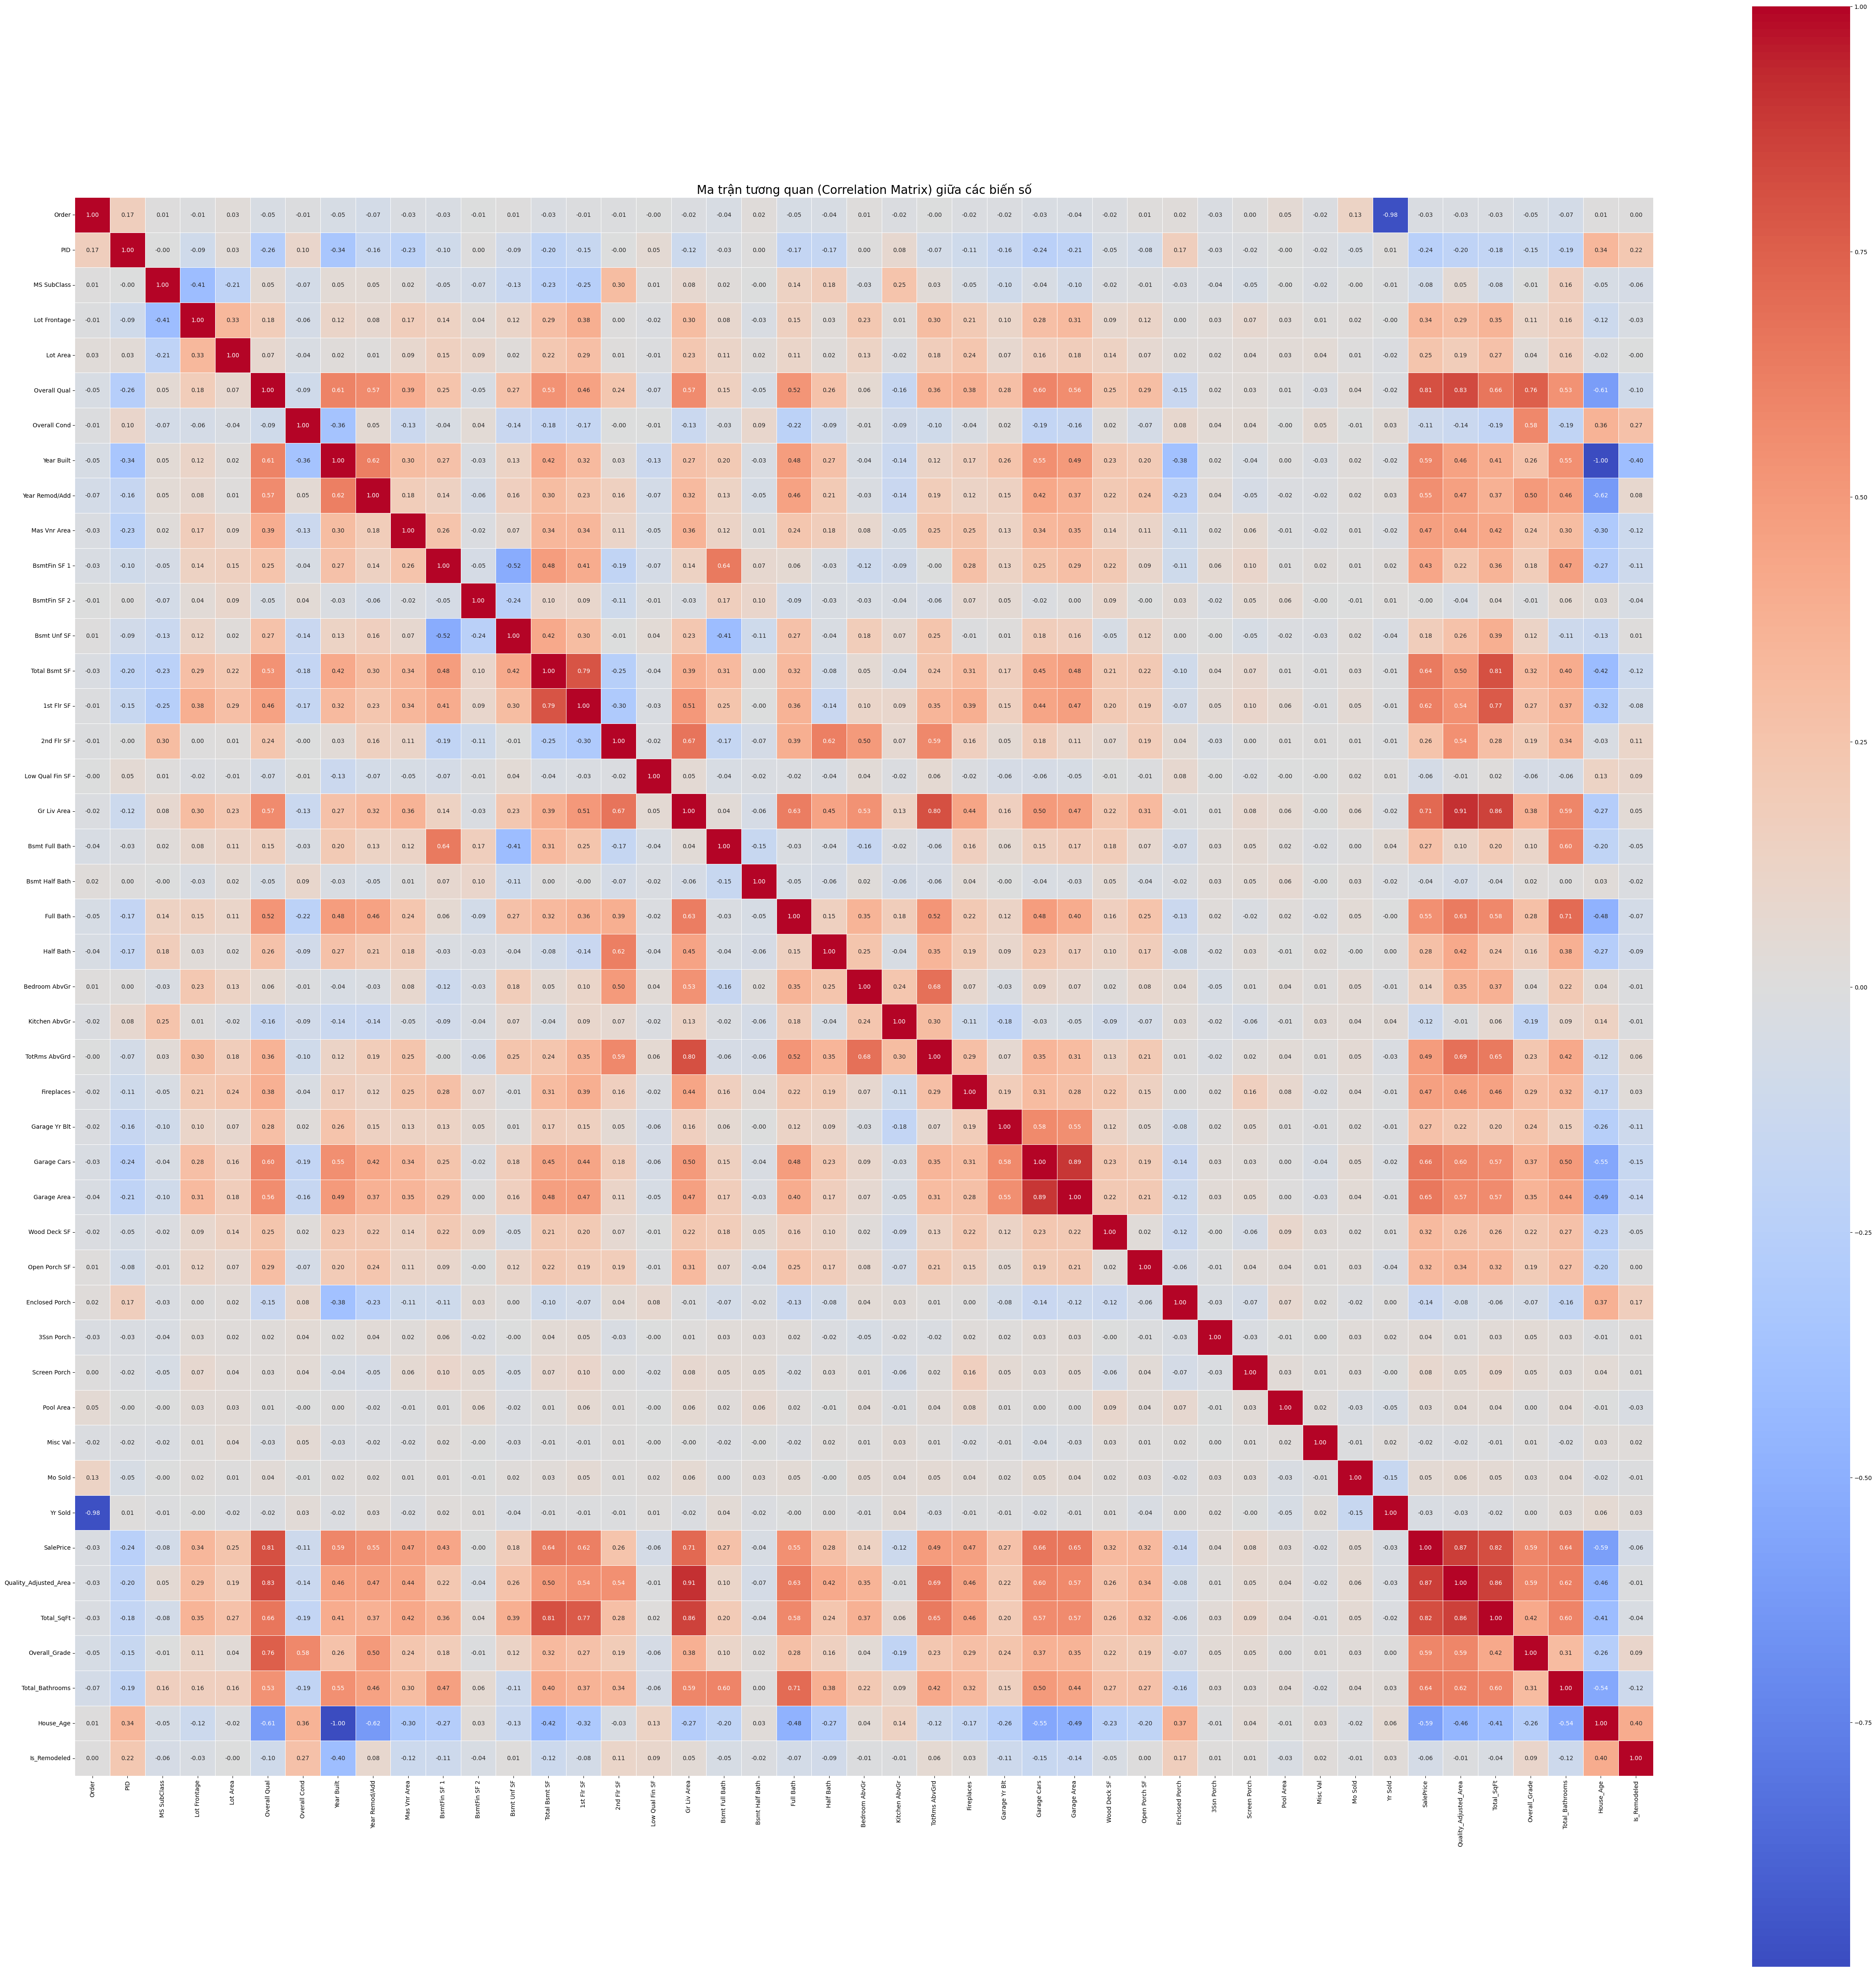

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


numeric_housing = dataset.select_dtypes(include=['number'])

corr = numeric_housing.corr()


plt.figure(figsize=(60, 60))
sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            square=True,
            linewidths=0.5)
plt.title("Ma trận tương quan (Correlation Matrix) giữa các biến số", fontsize=20)
plt.show()

### encoding variable

In [14]:
X = dataset.drop(columns=["Order", "PID", "SalePrice"], errors="ignore")
y = dataset["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.copy()
X_test = X_test.copy()

# BƯỚC 1: ORDINAL ENCODING (MÃ HÓA THỨ BẬC)

# Bảng từ điển ánh xạ điểm số dựa trên các giá trị điền khuyết của bạn
qual_mapping = {
    "NoPool": 0, "NoFireplace": 0, "noBsmt": 0, "NoGarage": 0,
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}

ordinal_cols = [
    "Exter Qual", "Exter Cond", "Bsmt Qual", "Bsmt Cond",
    "Heating QC", "Kitchen Qual", "Fireplace Qu", "Garage Qual",
    "Garage Cond", "Pool QC"
]

for col in ordinal_cols:
    if col in X_train.columns:
        X_train[col] = X_train[col].replace(qual_mapping)
    if col in X_test.columns:
        X_test[col] = X_test[col].replace(qual_mapping)

# BƯỚC 2: OUT-OF-FOLD SMOOTHED TARGET ENCODING

class OOFSmoothedTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, m=10.0, n_splits=5):
        self.m = m
        self.n_splits = n_splits
        self.mappings_ = {}
        self.global_mean_ = 0.0

    def fit(self, X, y):
        # Tính toán mapping trên TOÀN BỘ tập train để sau này dùng cho tập Test (Dữ liệu tương lai)
        self.global_mean_ = y.mean()
        df = pd.DataFrame(X).copy()
        df["__target"] = y.values

        for col in df.columns:
            if col == "__target":
                continue
            stats = df.groupby(col)["__target"].agg(["count", "mean"])
            smoothed = (stats["count"] * stats["mean"] + self.m * self.global_mean_) / (stats["count"] + self.m)
            self.mappings_[col] = smoothed.to_dict()
        return self

    def fit_transform(self, X, y):
        # Chạy fit để lưu thông số cho tập Test
        self.fit(X, y)

        df = pd.DataFrame(X).copy()
        df["__target"] = y.values
        X_out = pd.DataFrame(X).copy()

        kf = KFold(n_splits=self.n_splits, shuffle=True, random_state=42)

        for col in df.columns:
            if col == "__target":
                continue
            X_out[col] = np.nan

            # Vòng lặp tính trung bình trên tập Train-fold và gán cho Val-fold
            for train_idx, val_idx in kf.split(df):
                train_fold = df.iloc[train_idx]
                val_fold = df.iloc[val_idx]

                fold_global_mean = train_fold["__target"].mean()
                stats = train_fold.groupby(col)["__target"].agg(["count", "mean"])
                smoothed = (stats["count"] * stats["mean"] + self.m * fold_global_mean) / (stats["count"] + self.m)

                # Gán kết quả vào phần val_fold
                X_out.loc[val_fold.index, col] = val_fold[col].map(smoothed).fillna(fold_global_mean)

        return X_out

    def transform(self, X):
        # Hàm này chỉ dùng khi bạn dự đoán trên tập dữ liệu mới hoàn toàn (Test set)
        X_out = pd.DataFrame(X).copy()
        for col in X_out.columns:
            if col in self.mappings_:
                X_out[col] = X_out[col].map(self.mappings_[col]).fillna(self.global_mean_)
        return X_out

target_enc_cols = ["Neighborhood", "Exterior 1st", "Exterior 2nd"]

# Khởi tạo và sử dụng hàm fit_transform để tự động chạy cơ chế K-Fold
target_encoder = OOFSmoothedTargetEncoder(m=10.0, n_splits=5)
# 1. fit_transform TRÊN TẬP TRAIN (Sử dụng K-Fold nội bộ tập Train, an toàn tuyệt đối)
X_train[target_enc_cols] = target_encoder.fit_transform(X_train[target_enc_cols], y_train)

# 2. CHỈ transform TRÊN TẬP TEST (Áp dụng bản đồ mapping từ Train sang, không động vào y_test)
X_test[target_enc_cols] = target_encoder.transform(X_test[target_enc_cols])


# BƯỚC 3: ONE-HOT ENCODING (MÃ HÓA 0-1)

# Tự động quét tìm tất cả các cột dữ liệu chữ còn lại trong bảng
remaining_categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

if len(remaining_categorical_cols) > 0:
    oh_encoder = OneHotEncoder(sparse_output=False, drop="first", handle_unknown="ignore")

    # 1. fit_transform trên tập TRAIN để học từ điển các từ xuất hiện trong tập Train
    oh_train_matrix = oh_encoder.fit_transform(X_train[remaining_categorical_cols])

    # 2. CHỈ transform trên tập TEST (Nếu tập test xuất hiện từ lạ, handle_unknown='ignore' sẽ tự biến nó thành các cột 0)
    oh_test_matrix = oh_encoder.transform(X_test[remaining_categorical_cols])

    # Lấy tên cột mới được sinh ra từ tập Train
    encoded_colnames = oh_encoder.get_feature_names_out(remaining_categorical_cols)

    # Chuyển thành DataFrame tương ứng với Index của từng tập
    oh_train_df = pd.DataFrame(oh_train_matrix, columns=encoded_colnames, index=X_train.index)
    oh_test_df = pd.DataFrame(oh_test_matrix, columns=encoded_colnames, index=X_test.index)

    # Xóa cột chữ cũ và nối cột số One-Hot mới vào cho cả Train và Test
    X_train = pd.concat([X_train.drop(columns=remaining_categorical_cols), oh_train_df], axis=1)
    X_test = pd.concat([X_test.drop(columns=remaining_categorical_cols), oh_test_df], axis=1)

print(f"Kích thước tập X_train hiện tại: {X_train.shape}")
print(f"Kích thước tập X_test hiện tại: {X_test.shape}")

# Kiểm tra lại xem còn cột chữ nào sót lại không (Kỳ vọng kết quả là trống)
remaining_objects_train = X_train.select_dtypes(include=['object']).columns.tolist()
print(f"Các cột dữ liệu chữ còn sót lại trong tập train: {remaining_objects_train}")

Kích thước tập X_train hiện tại: (2316, 186)
Kích thước tập X_test hiện tại: (579, 186)
Các cột dữ liệu chữ còn sót lại trong tập train: []


/tmp/ipykernel_2280/2805098721.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train[col] = X_train[col].replace(qual_mapping)
/tmp/ipykernel_2280/2805098721.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test[col] = X_test[col].replace(qual_mapping)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [5, 19, 21, 27] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


### correlation graph with target variable

In [15]:
corr = dataset.corr(numeric_only=True)
# lay cot bien muc tieu tuong quan voi chinh no
corr_with_target = corr['SalePrice'].drop('SalePrice').sort_values(ascending=False)

print("Top biến tăng giá nhà:\n", corr_with_target.head(15))
print("\nTop biến giảm giá nhà:\n", corr_with_target.tail(15))

Top biến tăng giá nhà:
 Quality_Adjusted_Area    0.869078
Total_SqFt               0.815516
Overall Qual             0.810021
Gr Liv Area              0.711546
Garage Cars              0.659159
Garage Area              0.649288
Total Bsmt SF            0.643760
Total_Bathrooms          0.636536
1st Flr SF               0.623638
Year Built               0.593382
Overall_Grade            0.591650
Year Remod/Add           0.552175
Full Bath                0.546555
TotRms AbvGrd            0.486232
Mas Vnr Area             0.474754
Name: SalePrice, dtype: float64

Top biến giảm giá nhà:
 3Ssn Porch         0.038630
Pool Area          0.033738
BsmtFin SF 2      -0.004726
Misc Val          -0.017558
Order             -0.027334
Yr Sold           -0.033410
Bsmt Half Bath    -0.042401
Low Qual Fin SF   -0.062730
Is_Remodeled      -0.063138
MS SubClass       -0.079779
Overall Cond      -0.109623
Kitchen AbvGr     -0.123511
Enclosed Porch    -0.143542
PID               -0.242359
House_Age        

In [16]:
dataset.shape

(2895, 88)

### đánh giá điểm MI

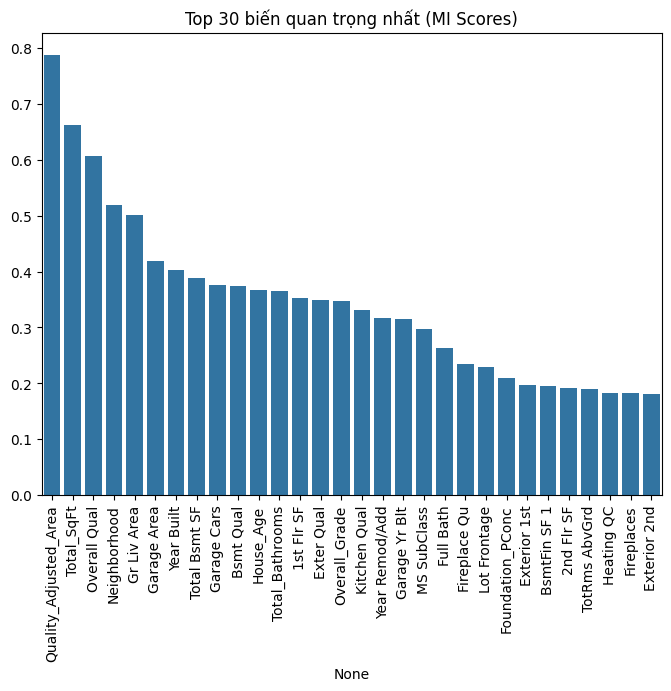

Quality_Adjusted_Area    0.787715
Total_SqFt               0.662039
Overall Qual             0.606472
Neighborhood             0.519540
Gr Liv Area              0.502071
Garage Area              0.418076
Year Built               0.402423
Total Bsmt SF            0.388164
Garage Cars              0.376053
Bsmt Qual                0.374383
House_Age                0.367474
Total_Bathrooms          0.364939
1st Flr SF               0.352566
Exter Qual               0.348817
Overall_Grade            0.347386
Name: MI Scores, dtype: float64


In [17]:
#  diem tuong quan MI
X_mi = X_train.copy()

X_mi = X_mi.fillna(0)
y_mi = y_train.copy()

mi_scores = mutual_info_regression(X_mi, y_mi, random_state=42)
mi_scores_series = pd.Series(mi_scores, name="MI Scores", index=X_mi.columns)
mi_scores_series = mi_scores_series.sort_values(ascending=False)

plt.figure(figsize=(8, 6))
# Lấy Top 30 biến quan trọng nhất để vẽ
sns.barplot(x=mi_scores_series.head(30).index, y=mi_scores_series.head(30).values)
plt.xticks(rotation=90)
plt.title("Top 30 biến quan trọng nhất (MI Scores)")
plt.show()

print(mi_scores_series.head(15))

In [18]:
dataset.shape

(2895, 88)

### dementionality reduction

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
pca = PCA(n_components=0.95, random_state=42)

X_train = pca.fit_transform(X_train_scaled)
X_test = pca.transform(X_test_scaled)
print(X_train.shape)
X_test.shape

(2316, 123)


(579, 123)

### train model sau khi feature engineering với ridge



In [20]:
X = dataset.drop(columns=["Order", "PID", "SalePrice"], errors="ignore")
y = dataset["SalePrice"]

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_train_log = np.log1p(y_train)
model = Ridge(alpha=1.0)
model.fit(X_train, y_train_log)

y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)

rmse_ridge = root_mean_squared_error(y_test, y_pred)
r2_ridge = r2_score(y_test, y_pred)

print("ket qua huan luyen mo hinh5")
print(f"RMSE: ${rmse_ridge:,.2f} USD")
print(f"R2 Score: {r2_ridge:.4f} ({r2_ridge*100:.2f}%)")

# RMSE: $21,759.48 USD
# R2 Score: 0.9131 (91.31%)

# ket qua huan luyen mo hinh chua giam chieu du lieu
# RMSE: $20,731.00 USD
# R2 Score: 0.9211 (92.11%)


ket qua huan luyen mo hinh5
RMSE: $21,759.48 USD
R2 Score: 0.9131 (91.31%)


### base model - Ridge







In [21]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ames-housing-prices/AmesHousing.csv')

numeric_df = df.select_dtypes(include=[np.number])

numeric_df = numeric_df.fillna(numeric_df.median())

X_base = numeric_df.drop(columns=['Order', 'SalePrice','PID'])
y_base = numeric_df['SalePrice']

# chia tap du lieu
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_base, y_base, test_size=0.2, random_state=42)

base_model = Ridge(alpha=1.0)
base_model.fit(X_train_b, y_train_b)

y_pred_b = base_model.predict(X_test_b)

rmse_base = root_mean_squared_error(y_test_b, y_pred_b)
r2_base = r2_score(y_test_b, y_pred_b)

print("ket qua")
print(f"RMSE: {rmse_base:,.2f}")
print(f"R2 Score: {r2_base:.4f}")

ket qua
RMSE: 36,229.51
R2 Score: 0.8363


### base model linear regression


In [22]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ames-housing-prices/AmesHousing.csv')

numeric_df = df.select_dtypes(include=[np.number])

numeric_df = numeric_df.fillna(numeric_df.median())

X_base = numeric_df.drop(columns=['Order', 'SalePrice','PID'])
y_base = numeric_df['SalePrice']

# chia tap du lieu
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_base, y_base, test_size=0.2, random_state=42)

base_model = LinearRegression()
base_model.fit(X_train_b, y_train_b)

y_pred_b = base_model.predict(X_test_b)

rmse_base = root_mean_squared_error(y_test_b, y_pred_b)
r2_base = r2_score(y_test_b, y_pred_b)

print("ket qua")
print(f"RMSE: {rmse_base:,.2f}")
print(f"R2 Score: {r2_base:.4f}")

ket qua
RMSE: 36,229.64
R2 Score: 0.8363


### linear regression model sau khi feature engineering

In [23]:
# X = dataset.drop(columns=["Order", "PID", "SalePrice"], errors="ignore")
# y = dataset["SalePrice"]

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# y_train_log = np.log1p(y_train)
model = LinearRegression()
model.fit(X_train, y_train_log)

y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)

rmse_lr = root_mean_squared_error(y_test, y_pred)
r2_lr = r2_score(y_test, y_pred)

print("ket qua huan luyen mo hinh5")
print(f"RMSE: ${rmse_lr:,.2f} USD")
print(f"R2 Score: {r2_lr:.4f} ({r2_lr*100:.2f}%)")
3



# RMSE: $21,761.48 USD
# R2 Score: 0.9130 (91.30%)
# ket qua huan luyen mo hinh chua giam chieu du lieu
# RMSE: $20,844.08 USD
# R2 Score: 0.9202 (92.02%)

ket qua huan luyen mo hinh5
RMSE: $21,761.48 USD
R2 Score: 0.9130 (91.30%)


3

In [24]:

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

rf_model.fit(X_train, y_train_log)

y_pred_log_rf = rf_model.predict(X_test)

y_pred_rf = np.expm1(y_pred_log_rf)

rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n--- KẾT QUẢ HUÂN LUYỆN MÔ HÌNH RANDOM FOREST ---")
print(f"RMSE: ${rmse_rf:,.2f} USD")
print(f"R2 Score: {r2_rf:.4f} ({r2_rf*100:.2f}%)")
"""### 7. BẢNG SO SÁNH TỔNG HỢP (BENCHMARK TABLE)"""
summary_df = pd.DataFrame({
    "Mô hình": ["Linear Regression (Có PCA)", "Ridge Regression (Có PCA)", "Random Forest (Gốc)"],
    "RMSE (USD)": [f"${rmse_lr:,.2f}", f"${rmse_ridge:,.2f}", f"${rmse_rf:,.2f}"],
    "R2 Score (%)": [f"{r2_lr*100:.2f}%", f"{r2_ridge*100:.2f}%", f"{r2_rf*100:.2f}%"]
})

print("\n--- BẢNG SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH ---")
print(summary_df.to_string(index=False))


--- KẾT QUẢ HUÂN LUYỆN MÔ HÌNH RANDOM FOREST ---
RMSE: $22,253.76 USD
R2 Score: 0.9091 (90.91%)

--- BẢNG SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH ---
                   Mô hình RMSE (USD) R2 Score (%)
Linear Regression (Có PCA) $21,761.48       91.30%
 Ridge Regression (Có PCA) $21,759.48       91.31%
       Random Forest (Gốc) $22,253.76       90.91%


In [ ]:
### base model random forest

from sklearn.ensemble import RandomForestRegressor

# 1. Đọc lại dữ liệu gốc
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ames-housing-prices/AmesHousing.csv')

# 2. Chỉ lọc các thuộc tính số (bỏ qua các cột dạng chữ)
numeric_df = df.select_dtypes(include=[np.number])

# 3. Điền giá trị thiếu bằng trung vị (median)
numeric_df = numeric_df.fillna(numeric_df.median())

# 4. Tách đặc trưng (X) và biến mục tiêu (y) dạng gốc (không dùng Log Transform)
X_base = numeric_df.drop(columns=['Order', 'SalePrice','PID'])
y_base = numeric_df['SalePrice']

# 5. Chia tập dữ liệu train/test theo tỷ lệ 80/20
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_base, y_base, test_size=0.2, random_state=42)

# 6. Khởi tạo và huấn luyện mô hình Random Forest cơ sở
base_rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
base_rf_model.fit(X_train_b, y_train_b)

# 7. Dự đoán trên tập test cơ sở
y_pred_b_rf = base_rf_model.predict(X_test_b)

# 8. Tính toán các chỉ số đánh giá hiệu năng
rmse_base_rf = root_mean_squared_error(y_test_b, y_pred_b_rf)
r2_base_rf = r2_score(y_test_b, y_pred_b_rf)

# 9. In kết quả
print("ket qua base model Random Forest")
print(f"RMSE: ${rmse_base_rf:,.2f} USD")
print(f"R2 Score: {r2_base_rf:.4f} ({r2_base_rf*100:.2f}%)")

ket qua base model Random Forest
RMSE: $27,040.95 USD
R2 Score: 0.9088 (90.88%)
